Importing the libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report



Configuration (Model hyperparameters)

In [3]:
RANDOM_STATE = 42
TARGET_LABELS = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
RF_BEST_PARAMS = {'n_estimators': 171, 'max_depth': None, 'min_samples_leaf': 3}
GB_PARAMS = {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3}


Data Preparation (Cleaning the data and defining features and targets)

In [4]:
# Load the dataset
df = pd.read_csv("machine failure.csv")

# Drop unique IDs and the overall 'Machine failure' column
df_processed = df.drop(columns=['UDI', 'Product ID'])

# One-hot encode the 'Type' column (M, L, H)
df_processed = pd.get_dummies(df_processed, columns=['Type'], drop_first=True)

# Define features (X) and targets (Y)
Y = df_processed[TARGET_LABELS]
X = df_processed.drop(columns=TARGET_LABELS + ['Machine failure'])



Creating feature corelation heatmap

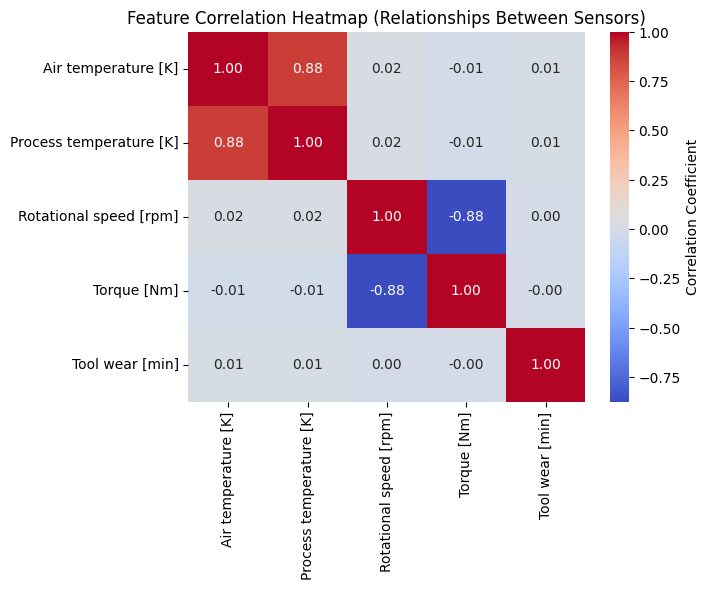

In [27]:
# Select numeric columns for correlation analysis
numeric_features = ['Air temperature [K]', 'Process temperature [K]', 
                    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
corr_matrix = df_processed[numeric_features].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Feature Correlation Heatmap (Relationships Between Sensors)')
plt.show()

Splitting the data

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=RANDOM_STATE)

Model function and evaluation

In [21]:
#function created to train and evaluate different models (A. and B.) and also return a failure classifiaction report
def train_and_evaluate_model(base_classifier, model_name, X_train, Y_train, X_test, Y_test): 
    
    # Wrap the classifier for Multi-Label output
    multi_target_model = MultiOutputClassifier(base_classifier)
    
    # Train the model
    multi_target_model.fit(X_train, Y_train)
    
    # Predict and evaluate
    Y_pred = multi_target_model.predict(X_test)
    
    # making the report
    report = classification_report(Y_test, Y_pred, target_names=TARGET_LABELS, 
                                   output_dict=True, zero_division=0)
    
    # Extract only the key failure metrics
    report_df = pd.DataFrame(report).transpose() #making the transpose
    failure_report = report_df.loc[TARGET_LABELS].copy() #using only the required labels
    return failure_report[['precision', 'recall', 'f1-score', 'support']]
    
# --- A. Tuned Random Forest Classifier (RF) ---
rf_classifier = RandomForestClassifier(
    n_estimators=RF_BEST_PARAMS['n_estimators'], max_depth=RF_BEST_PARAMS['max_depth'], 
    min_samples_leaf=RF_BEST_PARAMS['min_samples_leaf'], random_state=RANDOM_STATE, 
    class_weight='balanced'
)
rf_results = train_and_evaluate_model(rf_classifier, "Tuned Random Forest", X_train, Y_train, X_test, Y_test)
print(rf_results)

# --- B. Gradient Boosting Classifier (GB) ---
gb_classifier = GradientBoostingClassifier(
    n_estimators=GB_PARAMS['n_estimators'], learning_rate=GB_PARAMS['learning_rate'], 
    max_depth=GB_PARAMS['max_depth'], random_state=RANDOM_STATE
)
gb_results = train_and_evaluate_model(gb_classifier, "Gradient Boosting", X_train, Y_train, X_test, Y_test)
print(gb_results)


     precision    recall  f1-score  support
TWF   1.000000  0.090909  0.166667     11.0
HDF   0.600000  0.705882  0.648649     17.0
PWF   0.722222  0.650000  0.684211     20.0
OSF   0.846154  0.611111  0.709677     18.0
RNF   0.000000  0.000000  0.000000      6.0
     precision    recall  f1-score  support
TWF   0.000000  0.000000  0.000000     11.0
HDF   0.812500  0.764706  0.787879     17.0
PWF   0.761905  0.800000  0.780488     20.0
OSF   0.923077  0.666667  0.774194     18.0
RNF   0.000000  0.000000  0.000000      6.0


Final comparison and heatmap

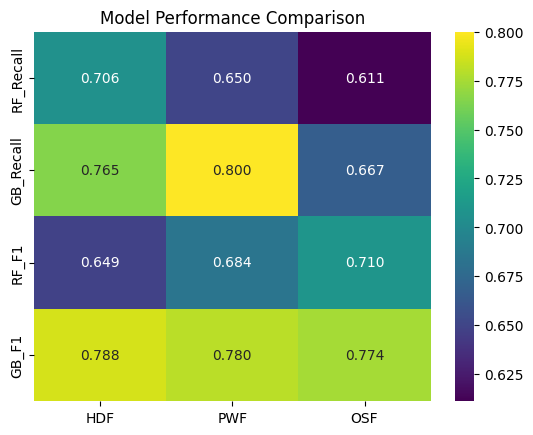

In [26]:
# Combine results into one DataFrame
final_comparison_df = pd.concat(
    [rf_results.add_prefix('RF_'), gb_results.add_prefix('GB_')], 
    axis=1
)

# Rearrange and simplify column names
final_comparison_df = final_comparison_df[['RF_recall', 'GB_recall', 'RF_f1-score', 'GB_f1-score', 'RF_precision', 'GB_precision', 'RF_support']]

# --- CREATE MODEL PERFORMANCE HEATMAP (Report Visual) ---
heatmap_data = pd.DataFrame({
    'RF_Recall': rf_results['recall'],
    'GB_Recall': gb_results['recall'],
    'RF_F1': rf_results['f1-score'],
    'GB_F1': gb_results['f1-score']
}).loc[['HDF', 'PWF', 'OSF']].T 


# Plot heatmap
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap='viridis')
plt.title('Model Performance Comparison')
plt.show()

Final Output

In [28]:
print("                 FINAL PROJECT OUTPUT AND COMPARISON")
print("\n--- PERFORMANCE COMPARISON: Random Forest and Gradient Boosting ---")
print(final_comparison_df.round(4))
print("\nFinal Recommendation: Gradient Boosting is the better model.")

                 FINAL PROJECT OUTPUT AND COMPARISON

--- PERFORMANCE COMPARISON: Random Forest and Gradient Boosting ---
     RF_recall  GB_recall  RF_f1-score  GB_f1-score  RF_precision  \
TWF     0.0909     0.0000       0.1667       0.0000        1.0000   
HDF     0.7059     0.7647       0.6486       0.7879        0.6000   
PWF     0.6500     0.8000       0.6842       0.7805        0.7222   
OSF     0.6111     0.6667       0.7097       0.7742        0.8462   
RNF     0.0000     0.0000       0.0000       0.0000        0.0000   

     GB_precision  RF_support  
TWF        0.0000        11.0  
HDF        0.8125        17.0  
PWF        0.7619        20.0  
OSF        0.9231        18.0  
RNF        0.0000         6.0  

Final Recommendation: Gradient Boosting is the better model.
